In [1]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
from lattice_mp import SpinConfiguration

nx = 6
ny = 2
n = nx * ny

def get_gap_vs_U(_delta = 1., lamb = 1., S = 1):
    sc = SpinConfiguration(nx, ny, int(n/2), delta=_delta, lamb=lamb, S=S)
    sc_plus = SpinConfiguration(nx, ny, int(n/2) + 1, delta=_delta, lamb=lamb, S=S)
    sc_minus = SpinConfiguration(nx, ny, int(n/2) - 1, delta=_delta, lamb=lamb, S=S)

    gap_plus = []
    gap_minus = []

    _min = -3
    _max = 5
    steps = 10*(_max - _min) + 1
    u_range = np.logspace(_min, _max, base = 10, num = steps)

    for u in tqdm(u_range):
        # U that should be used is up to 1e5
        sc.generate_hamiltonian(U = u)
        sc.get_eigva_eigve(10)
        mine_0 = sc.get_ground_state()[0]

        sc_plus.generate_hamiltonian(U = u)
        sc_plus.get_eigva_eigve(10)
        mine_plus = sc_plus.get_ground_state()[0]

        sc_minus.generate_hamiltonian(U = u)
        sc_minus.get_eigva_eigve(10)
        mine_minus = sc_minus.get_ground_state()[0]

        gap_plus.append(mine_plus - mine_0)
        gap_minus.append(mine_minus - mine_0)
    
    return u_range, gap_plus, gap_minus


In [3]:
delta = 1.
lamb = 0.
S = 1/2
u_range, g1, g2 = get_gap_vs_U(_delta = delta, lamb = lamb, S = S)
#u_range, g1 = get_gap_vs_U(_delta = delta, lamb = lamb, S = S)

100%|██████████| 81/81 [00:25<00:00,  3.18it/s]


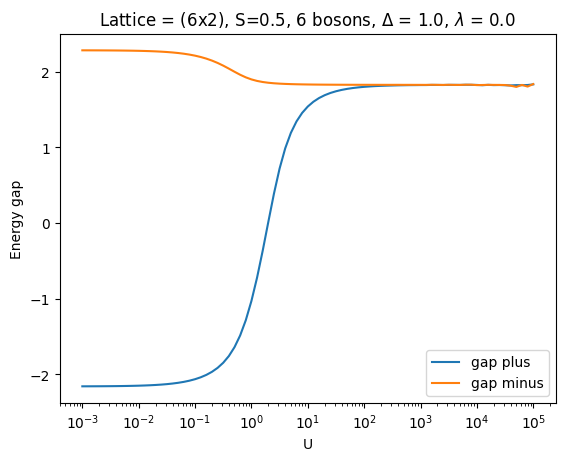

In [13]:
plt.plot(u_range, g1, label=r'gap plus')
plt.plot(u_range, np.abs(g2), label=r'gap minus')
plt.xscale('log')
plt.legend()
plt.xlabel('U')
plt.title(rf'Lattice = ({nx}x{ny}), S={S}, {int(n/2)} bosons, $\Delta$ = {delta}, $\lambda$ = {lamb}')
plt.ylabel('Energy gap')
#plt.ylim([0, None])
plt.show()